## **Read data and Imports**

In [2]:
# =========================================================
# 0) IMPORTS + REPRODUCIBILITY
# =========================================================

import os
import random
import copy
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.15.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# =========================================================
# 1) PATHS + CONFIGURATION
# =========================================================

TRAIN_CSV = "../../../Data/dataset_split/train/train.csv"
VAL_CSV   = "../../../Data/dataset_split/val/val.csv"
TEST_CSV  = "../../../Data/dataset_split/test/test.csv"

TRAIN_IMAGE_DIR = "../../../Data/dataset_split/train/images_processed"
VAL_IMAGE_DIR   = "../../../Data/dataset_split/val/images_processed"
TEST_IMAGE_DIR  = "../../../Data/dataset_split/test/images_processed"

# This notebook is optimized for 5-class DR_ICDR severity classification.
TARGET_MODE = "5class"

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
EMB_BATCH_SIZE = 16

# 5-class is very imbalanced. Do not fully balance to class 0.
# We use class-specific partial oversampling in Cell 7.
MINORITY_TARGET_COUNT_5CLASS = {
    1: 450,   # class 1 is very small
    2: 500,   # class 2 usually has more samples but is often confused
    3: 450,   # class 3 is extremely small, avoid too much duplication
    4: 550    # class 4 is clinically important and often missed
}

# Smaller K reduces majority-class drowning in the graph.
K_NEIGHBORS = 5
PCA_COMPONENTS_FOR_GRAPH = 96

# These features can improve performance, but some are ophthalmic annotations.
# For a stricter no-leakage experiment, set USE_OPHTHALMIC_METADATA=False.
USE_OPHTHALMIC_METADATA = True

safe_features = [
    "patient_age",
    "patient_sex",
    "diabetes"
]

ophthalmic_metadata_features = [
    "optic_disc",
    "vessels",
    "macula",
    "macular_edema",
    "drusens",
    "myopic_fundus"
]

tabular_features = safe_features + ophthalmic_metadata_features if USE_OPHTHALMIC_METADATA else safe_features

print("TARGET_MODE:", TARGET_MODE)
print("Tabular features:", tabular_features)
print("5-class oversampling targets:", MINORITY_TARGET_COUNT_5CLASS)
print("Train CSV exists:", os.path.exists(TRAIN_CSV), TRAIN_CSV)
print("Val CSV exists  :", os.path.exists(VAL_CSV), VAL_CSV)
print("Test CSV exists :", os.path.exists(TEST_CSV), TEST_CSV)
print("Train image dir exists:", os.path.exists(TRAIN_IMAGE_DIR), TRAIN_IMAGE_DIR)
print("Val image dir exists  :", os.path.exists(VAL_IMAGE_DIR), VAL_IMAGE_DIR)
print("Test image dir exists :", os.path.exists(TEST_IMAGE_DIR), TEST_IMAGE_DIR)

TARGET_MODE: 5class
Tabular features: ['patient_age', 'patient_sex', 'diabetes', 'optic_disc', 'vessels', 'macula', 'macular_edema', 'drusens', 'myopic_fundus']
5-class oversampling targets: {1: 450, 2: 500, 3: 450, 4: 550}
Train CSV exists: True ../../../Data/dataset_split/train/train.csv
Val CSV exists  : True ../../../Data/dataset_split/val/val.csv
Test CSV exists : True ../../../Data/dataset_split/test/test.csv
Train image dir exists: True ../../../Data/dataset_split/train/images_processed
Val image dir exists  : True ../../../Data/dataset_split/val/images_processed
Test image dir exists : True ../../../Data/dataset_split/test/images_processed


In [4]:
# =========================================================
# 2) LOAD DATA
# =========================================================

train_data = pd.read_csv(TRAIN_CSV)
val_data   = pd.read_csv(VAL_CSV)
test_data  = pd.read_csv(TEST_CSV)

print("Raw shapes:")
print("train_data:", train_data.shape)
print("val_data  :", val_data.shape)
print("test_data :", test_data.shape)
print()
print("Train columns:")
print(train_data.columns.tolist())

Raw shapes:
train_data: (13015, 34)
val_data  : (1632, 34)
test_data : (1619, 34)

Train columns:
['image_id', 'patient_id', 'camera', 'patient_age', 'comorbidities', 'diabetes_time_y', 'insuline', 'patient_sex', 'exam_eye', 'diabetes', 'nationality', 'optic_disc', 'vessels', 'macula', 'DR_SDRG', 'DR_ICDR', 'focus', 'Illuminaton', 'image_field', 'artifacts', 'diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc', 'other', 'quality']


## **Preprocessing**

In [5]:
# =========================================================
# 3) STANDARDIZE COLUMNS + CREATE TARGET
# =========================================================

def standardize_columns(df):
    df = df.copy()

    if "exam_eye" in df.columns:
        eye_numeric = pd.to_numeric(df["exam_eye"], errors="coerce")
        unique_vals = set(eye_numeric.dropna().astype(int).unique().tolist())
        if unique_vals.issubset({1, 2}):
            df["exam_eye"] = eye_numeric.map({1: 0, 2: 1})
        else:
            df["exam_eye"] = eye_numeric

    binary_like_cols = ["vessels", "macula", "patient_sex", "optic_disc"]
    for col in binary_like_cols:
        if col in df.columns:
            numeric_col = pd.to_numeric(df[col], errors="coerce")
            vals = set(numeric_col.dropna().astype(int).unique().tolist())
            if vals.issubset({1, 2}):
                df[col] = numeric_col.map({1: 0, 2: 1})
            else:
                df[col] = numeric_col

    if "diabetes" in df.columns:
        if df["diabetes"].dtype == "object":
            df["diabetes"] = (
                df["diabetes"].astype(str).str.strip().str.lower()
                .map({"yes": 1, "y": 1, "true": 1, "1": 1, "no": 0, "n": 0, "false": 0, "0": 0})
            )
        else:
            df["diabetes"] = pd.to_numeric(df["diabetes"], errors="coerce")

    return df


def create_target(df, target_mode):
    df = df.copy()
    if "DR_ICDR" not in df.columns:
        raise ValueError("DR_ICDR column is required for target creation.")

    dr = pd.to_numeric(df["DR_ICDR"], errors="coerce")

    if target_mode == "5class":
        df["target"] = dr.astype("Int64")
        class_names = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"]

    elif target_mode == "3class":
        # 0: No DR, 1: Mild/Moderate DR, 2: Severe DR
        df["target"] = dr.map(lambda x: 0 if x == 0 else (1 if x in [1, 2] else 2)).astype("Int64")
        class_names = ["No DR", "Mild/Moderate DR", "Severe DR"]

    elif target_mode == "binary":
        if "diabetic_retinopathy" in df.columns:
            y = pd.to_numeric(df["diabetic_retinopathy"], errors="coerce")
            df["target"] = (y > 0).astype("Int64")
        else:
            df["target"] = (dr > 0).astype("Int64")
        class_names = ["No DR", "DR"]

    else:
        raise ValueError("TARGET_MODE must be 'binary', '3class', or '5class'.")

    return df, class_names

train_data = standardize_columns(train_data)
val_data   = standardize_columns(val_data)
test_data  = standardize_columns(test_data)

train_data, CLASS_NAMES = create_target(train_data, TARGET_MODE)
val_data, _ = create_target(val_data, TARGET_MODE)
test_data, _ = create_target(test_data, TARGET_MODE)

TARGET = "target"
NUM_CLASSES = len(CLASS_NAMES)

print("NUM_CLASSES:", NUM_CLASSES)
print("CLASS_NAMES:", CLASS_NAMES)
print()
print("Image-level target distributions:")
print("Train:")
print(train_data[TARGET].value_counts().sort_index())
print("Val:")
print(val_data[TARGET].value_counts().sort_index())
print("Test:")
print(test_data[TARGET].value_counts().sort_index())

NUM_CLASSES: 5
CLASS_NAMES: ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']

Image-level target distributions:
Train:
target
0    12151
1      124
2      357
3       66
4      317
Name: count, dtype: Int64
Val:
target
0    1544
1      11
2      44
3       6
4      27
Name: count, dtype: Int64
Test:
target
0    1488
1      23
2      50
3       6
4      52
Name: count, dtype: Int64


In [6]:
# =========================================================
# 4) BASIC CLEANING
# =========================================================

def clean_dataframe(df, tabular_features, target):
    df = df.copy()

    required = ["image_id", "patient_id", "exam_eye", target]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    existing_features = [col for col in tabular_features if col in df.columns]

    for col in existing_features + [target, "exam_eye"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if "patient_age" in df.columns:
        df["patient_age"] = pd.to_numeric(df["patient_age"], errors="coerce")
        df["patient_age"] = df["patient_age"].fillna(df["patient_age"].median())

    df = df.dropna(subset=[target, "exam_eye", "patient_id", "image_id"]).reset_index(drop=True)
    df[target] = df[target].astype(int)

    return df, existing_features

train_data, tabular_features = clean_dataframe(train_data, tabular_features, TARGET)
val_data, _ = clean_dataframe(val_data, tabular_features, TARGET)
test_data, _ = clean_dataframe(test_data, tabular_features, TARGET)

print("Available tabular features:", tabular_features)
print("After cleaning:")
print("train_data:", train_data.shape)
print("val_data  :", val_data.shape)
print("test_data :", test_data.shape)

Available tabular features: ['patient_age', 'patient_sex', 'diabetes', 'optic_disc', 'vessels', 'macula', 'macular_edema', 'drusens', 'myopic_fundus']
After cleaning:
train_data: (13015, 35)
val_data  : (1632, 35)
test_data : (1619, 35)


In [7]:
# =========================================================
# 5) IMAGE PATHS
# =========================================================

def find_image_path(image_id, image_dir):
    image_id = str(image_id).strip()

    candidates = [image_id, image_id.lower(), image_id.upper()]
    exts = [".png", ".jpg", ".jpeg", ".JPG", ".JPEG", ".PNG"]

    for candidate in candidates:
        for ext in exts:
            path = os.path.join(image_dir, candidate + ext)
            if os.path.exists(path):
                return path

    # Fallback: if image_id already includes extension
    direct_path = os.path.join(image_dir, image_id)
    if os.path.exists(direct_path):
        return direct_path

    return None


def attach_image_paths(df, image_dir, name="df"):
    df = df.copy()
    print("--- Attaching image paths for", name, "---")
    print("Input shape:", df.shape)
    print("Image dir exists:", os.path.exists(image_dir), image_dir)

    df["image_path"] = df["image_id"].astype(str).apply(lambda x: find_image_path(x, image_dir))

    found = int(df["image_path"].notna().sum())
    missing = int(df["image_path"].isna().sum())
    print("Images found:", found)
    print("Images missing:", missing)

    if found == 0:
        raise ValueError(f"No images were matched for {name}. Check IMAGE_DIR and filenames.")

    df = df.dropna(subset=["image_path"]).reset_index(drop=True)
    print("Output shape:", df.shape)
    print()
    return df

train_data2 = attach_image_paths(train_data, TRAIN_IMAGE_DIR, "train")
val_data2   = attach_image_paths(val_data, VAL_IMAGE_DIR, "val")
test_data2  = attach_image_paths(test_data, TEST_IMAGE_DIR, "test")

--- Attaching image paths for train ---
Input shape: (13015, 35)
Image dir exists: True ../../../Data/dataset_split/train/images_processed
Images found: 13015
Images missing: 0
Output shape: (13015, 36)

--- Attaching image paths for val ---
Input shape: (1632, 35)
Image dir exists: True ../../../Data/dataset_split/val/images_processed
Images found: 1632
Images missing: 0
Output shape: (1632, 36)

--- Attaching image paths for test ---
Input shape: (1619, 35)
Image dir exists: True ../../../Data/dataset_split/test/images_processed
Images found: 1619
Images missing: 0
Output shape: (1619, 36)



In [8]:
# =========================================================
# 6) IMAGE-LEVEL -> PATIENT-LEVEL LEFT/RIGHT PAIRS
# =========================================================

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan


def build_patient_level_df(df, split_name):
    rows = []
    for patient_id, group in df.groupby("patient_id"):
        left_group = group[group["exam_eye"] == 0]
        right_group = group[group["exam_eye"] == 1]

        if len(left_group) == 0 or len(right_group) == 0:
            continue

        left_row = left_group.iloc[0]
        right_row = right_group.iloc[0]

        row = {
            "patient_id": patient_id,
            "left_image_path": left_row["image_path"],
            "right_image_path": right_row["image_path"],
            TARGET: int(max(left_row[TARGET], right_row[TARGET])),
            "split": split_name
        }

        # Patient-level tabular values: first valid value from either eye/group.
        for col in tabular_features:
            row[col] = first_non_null(group[col]) if col in group.columns else np.nan

        rows.append(row)

    out = pd.DataFrame(rows).reset_index(drop=True)
    return out

train_df = build_patient_level_df(train_data2, "train")
val_df   = build_patient_level_df(val_data2, "val")
test_df  = build_patient_level_df(test_data2, "test")

print("Patient-level shapes:")
print("train_df:", train_df.shape)
print("val_df  :", val_df.shape)
print("test_df :", test_df.shape)
print()
print("Patient-level target distributions:")
print("Train:")
print(train_df[TARGET].value_counts().sort_index())
print("Val:")
print(val_df[TARGET].value_counts().sort_index())
print("Test:")
print(test_df[TARGET].value_counts().sort_index())

print()
print("Patient overlap checks:")
print("Train-Val:", len(set(train_df.patient_id) & set(val_df.patient_id)))
print("Train-Test:", len(set(train_df.patient_id) & set(test_df.patient_id)))
print("Val-Test:", len(set(val_df.patient_id) & set(test_df.patient_id)))

Patient-level shapes:
train_df: (6094, 14)
val_df  : (764, 14)
test_df : (754, 14)

Patient-level target distributions:
Train:
target
0    5658
1      60
2     170
3      38
4     168
Name: count, dtype: int64
Val:
target
0    719
1      5
2     24
3      3
4     13
Name: count, dtype: int64
Test:
target
0    688
1      9
2     31
3      3
4     23
Name: count, dtype: int64

Patient overlap checks:
Train-Val: 0
Train-Test: 0
Val-Test: 0


## **Stage 1: EfficientNet + Tabular Training**

In [9]:
# =========================================================
# 7) CLASS-SPECIFIC PARTIAL OVERSAMPLING FOR 5-CLASS STAGE 1
# =========================================================

print("Before oversampling:")
print(train_df[TARGET].value_counts().sort_index())

balanced_parts = []
for cls in range(NUM_CLASSES):
    cls_df = train_df[train_df[TARGET] == cls].copy()
    current_count = len(cls_df)

    if current_count == 0:
        print(f"Warning: class {cls} has 0 samples in train.")
        continue

    if cls == 0:
        # Keep majority class unchanged. We do not duplicate normal cases.
        sampled_df = cls_df.copy()
    else:
        target_count = max(current_count, MINORITY_TARGET_COUNT_5CLASS.get(cls, current_count))
        sampled_df = cls_df.sample(
            n=target_count,
            replace=True,
            random_state=SEED + cls
        )

    balanced_parts.append(sampled_df)

train_df_balanced = pd.concat(balanced_parts, axis=0)
train_df_balanced = train_df_balanced.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("After oversampling:")
print(train_df_balanced[TARGET].value_counts().sort_index())
print("Final train_df_balanced shape:", train_df_balanced.shape)
print("Validation distribution unchanged:")
print(val_df[TARGET].value_counts().sort_index())
print("Test distribution unchanged:")
print(test_df[TARGET].value_counts().sort_index())

Before oversampling:
target
0    5658
1      60
2     170
3      38
4     168
Name: count, dtype: int64
After oversampling:
target
0    5658
1     450
2     500
3     450
4     550
Name: count, dtype: int64
Final train_df_balanced shape: (7608, 14)
Validation distribution unchanged:
target
0    719
1      5
2     24
3      3
4     13
Name: count, dtype: int64
Test distribution unchanged:
target
0    688
1      9
2     31
3      3
4     23
Name: count, dtype: int64


In [10]:
# =========================================================
# 8) TABULAR PREPROCESSING
# =========================================================

def prepare_tabular_df(df, features):
    out = df[features].copy()
    for col in features:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    return out

X_train_tab_raw = prepare_tabular_df(train_df_balanced, tabular_features)
X_val_tab_raw   = prepare_tabular_df(val_df, tabular_features)
X_test_tab_raw  = prepare_tabular_df(test_df, tabular_features)

imputer_stage1 = SimpleImputer(strategy="median")
scaler_stage1 = StandardScaler()

X_train_tab = imputer_stage1.fit_transform(X_train_tab_raw)
X_val_tab   = imputer_stage1.transform(X_val_tab_raw)
X_test_tab  = imputer_stage1.transform(X_test_tab_raw)

X_train_tab = scaler_stage1.fit_transform(X_train_tab).astype("float32")
X_val_tab   = scaler_stage1.transform(X_val_tab).astype("float32")
X_test_tab  = scaler_stage1.transform(X_test_tab).astype("float32")

y_train = train_df_balanced[TARGET].values.astype("int32")
y_val   = val_df[TARGET].values.astype("int32")
y_test  = test_df[TARGET].values.astype("int32")

print("X_train_tab:", X_train_tab.shape)
print("X_val_tab  :", X_val_tab.shape)
print("X_test_tab :", X_test_tab.shape)
print("y_train distribution:")
print(pd.Series(y_train).value_counts().sort_index())

X_train_tab: (7608, 9)
X_val_tab  : (764, 9)
X_test_tab : (754, 9)
y_train distribution:
0    5658
1     450
2     500
3     450
4     550
Name: count, dtype: int64


In [11]:
# =========================================================
# 9) IMAGE LOADER + CLASS-AWARE AUGMENTATION
# =========================================================

# Keep augmentations medically mild. Strong transformations can distort lesions.
minority_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.025),
    tf.keras.layers.RandomZoom(0.045),
    tf.keras.layers.RandomContrast(0.12),
    tf.keras.layers.RandomTranslation(0.025, 0.025),
], name="minority_class_augmentation")


# Additional tiny brightness jitter using tf.image; only applied to minority classes.
def brightness_jitter(img):
    img = tf.image.random_brightness(img, max_delta=0.035)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img


def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img


def augment_single_image(img):
    img = tf.expand_dims(img, axis=0)
    img = minority_augmentation(img, training=True)
    img = tf.squeeze(img, axis=0)
    img = brightness_jitter(img)
    return img


def make_dataset(left_paths, right_paths, tabular_data, labels, training=True, augment_minority=False):
    ds = tf.data.Dataset.from_tensor_slices((left_paths, right_paths, tabular_data, labels))

    def map_fn(lp, rp, tab, label):
        left_img = load_image(lp)
        right_img = load_image(rp)
        label_int = tf.cast(label, tf.int32)

        if training and augment_minority:
            # For 5-class DR_ICDR, all non-zero classes are minority disease classes.
            is_minority = tf.not_equal(label_int, 0)
            left_img = tf.cond(is_minority, lambda: augment_single_image(left_img), lambda: left_img)
            right_img = tf.cond(is_minority, lambda: augment_single_image(right_img), lambda: right_img)

        inputs = {
            "left_image_input": left_img,
            "right_image_input": right_img,
            "tabular_input": tf.cast(tab, tf.float32)
        }
        return inputs, label_int

    ds = ds.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(1500, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(
    train_df_balanced["left_image_path"].values,
    train_df_balanced["right_image_path"].values,
    X_train_tab,
    y_train,
    training=True,
    augment_minority=True
)

val_ds = make_dataset(
    val_df["left_image_path"].values,
    val_df["right_image_path"].values,
    X_val_tab,
    y_val,
    training=False,
    augment_minority=False
)

test_ds = make_dataset(
    test_df["left_image_path"].values,
    test_df["right_image_path"].values,
    X_test_tab,
    y_test,
    training=False,
    augment_minority=False
)

print("Datasets created successfully.")

2026-05-12 00:15:57.304484: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Datasets created successfully.


In [12]:
# =========================================================
# 10) FOCAL LOSS + MACRO F1 CALLBACK
# =========================================================

# Softer than previous extreme weights. This avoids predicting too many minority classes.
def get_stage1_alpha():
    return [1.0, 2.0, 2.2, 2.8, 2.8]


def sparse_categorical_focal_loss(gamma=1.1, alpha=None):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=NUM_CLASSES)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        ce = -y_true_one_hot * tf.math.log(y_pred)
        focal_factor = tf.pow(1.0 - y_pred, gamma)
        loss = focal_factor * ce

        if alpha is not None:
            alpha_tensor = tf.constant(alpha, dtype=tf.float32)
            alpha_weights = tf.gather(alpha_tensor, y_true)
            loss = loss * tf.expand_dims(alpha_weights, axis=-1)

        return tf.reduce_sum(loss, axis=-1)
    return loss_fn


class MacroMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_ds, y_val, class_names, name="val"):
        super().__init__()
        self.val_ds = val_ds
        self.y_val = y_val
        self.class_names = class_names
        self.name = name
        self.best_macro_f1 = -np.inf
        self.best_bal_acc = -np.inf
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        y_prob = self.model.predict(self.val_ds, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        macro_f1 = f1_score(self.y_val, y_pred, average="macro", zero_division=0)
        bal_acc = balanced_accuracy_score(self.y_val, y_pred)
        pred_dist = pd.Series(y_pred).value_counts().sort_index().to_dict()

        logs[f"{self.name}_macro_f1"] = macro_f1
        logs[f"{self.name}_balanced_accuracy"] = bal_acc

        print(f"{self.name} Macro F1: {macro_f1:.4f} | {self.name} Balanced Acc: {bal_acc:.4f} | Pred Dist: {pred_dist}")

        # Save by macro F1 first, balanced accuracy second.
        if (macro_f1 > self.best_macro_f1) or (np.isclose(macro_f1, self.best_macro_f1) and bal_acc > self.best_bal_acc):
            self.best_macro_f1 = macro_f1
            self.best_bal_acc = bal_acc
            self.best_weights = copy.deepcopy(self.model.get_weights())

    def on_train_end(self, logs=None):
        if self.best_weights is not None:
            self.model.set_weights(self.best_weights)
            print(f"Restored best weights by {self.name} Macro F1: {self.best_macro_f1:.4f}, Balanced Acc: {self.best_bal_acc:.4f}")

In [13]:
# =========================================================
# 11) STAGE 1 MODEL: EFFICIENTNET + TABULAR
# =========================================================

def build_image_encoder():
    image_input = layers.Input(shape=(224, 224, 3), name="image_encoder_input")

    # Images are loaded as [0,1]. EfficientNet expects [0,255].
    x = layers.Lambda(lambda t: t * 255.0, name="scale_0_1_to_0_255")(image_input)

    # Do not pass name=... here because some local Keras versions reject it.
    base = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3),
        pooling=None
    )
    base.trainable = False

    feat_map = base(x)
    gap = layers.GlobalAveragePooling2D(name="image_gap")(feat_map)
    emb = layers.Dense(256, activation="relu", name="image_embedding")(gap)
    emb = layers.Dropout(0.3)(emb)

    return Model(image_input, emb, name="efficientnet_image_encoder")


left_image_input = layers.Input(shape=(224, 224, 3), name="left_image_input")
right_image_input = layers.Input(shape=(224, 224, 3), name="right_image_input")
tabular_input = layers.Input(shape=(X_train_tab.shape[1],), name="tabular_input")

image_encoder = build_image_encoder()
left_emb = image_encoder(left_image_input)
right_emb = image_encoder(right_image_input)

tab = layers.Dense(64, activation="relu")(tabular_input)
tab = layers.BatchNormalization()(tab)
tab = layers.Dropout(0.3)(tab)
tab = layers.Dense(64, activation="relu", name="tabular_embedding")(tab)
tab = layers.Dropout(0.2)(tab)

combined = layers.Concatenate(name="patient_fusion")([left_emb, right_emb, tab])

x = layers.Dense(256, activation="relu")(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(NUM_CLASSES, activation="softmax", name="target_output")(x)

stage1_model = Model(
    inputs={
        "left_image_input": left_image_input,
        "right_image_input": right_image_input,
        "tabular_input": tabular_input
    },
    outputs=output,
    name="Stage1_EfficientNet_Tabular"
)

stage1_model.summary()

Model: "Stage1_EfficientNet_Tabular"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 tabular_input (InputLayer)  [(None, 9)]                  0         []                            
                                                                                                  
 dense (Dense)               (None, 64)                   640       ['tabular_input[0][0]']       
                                                                                                  
 batch_normalization (Batch  (None, 64)                   256       ['dense[0][0]']               
 Normalization)                                                                                   
                                                                                                  
 dropout_1 (Dropout)         (None, 64)                   0         ['ba

In [14]:
# =========================================================
# 12) TRAIN STAGE 1 - FROZEN EFFICIENTNET
# =========================================================

alpha = get_stage1_alpha()
print("Stage 1 alpha:", alpha)

macro_callback_stage1 = MacroMetricsCallback(val_ds, y_val, CLASS_NAMES, name="val")

stage1_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=sparse_categorical_focal_loss(gamma=1.1, alpha=alpha),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

history_stage1 = stage1_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        macro_callback_stage1,
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=9, restore_best_weights=False),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-7)
    ]
)

Stage 1 alpha: [1.0, 2.0, 2.2, 2.8, 2.8]
Epoch 1/30


2026-05-12 00:16:13.335266: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStage1_EfficientNet_Tabular/efficientnet_image_encoder/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-05-12 00:16:19.637241: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-05-12 00:16:19.951804: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-12 00:16:22.350764: I external/local_xla/xla/service/service.cc:168] XLA service 0x7ab39de3f580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-12 00:16:22.350816: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2026-05-12 00:16:22.358178: I tensorflow/compiler/mlir/ten

951/951 [==============================] - 103s 87ms/step - loss: 2.1802 - accuracy: 0.4260 - val_loss: 0.7453 - val_accuracy: 0.9005 - val_macro_f1: 0.1897 - val_balanced_accuracy: 0.1914 - lr: 5.0000e-05
Epoch 2/30
951/951 [==============================] - 82s 79ms/step - loss: 1.8821 - accuracy: 0.5335 - val_loss: 0.7251 - val_accuracy: 0.9385 - val_macro_f1: 0.1938 - val_balanced_accuracy: 0.1994 - lr: 5.0000e-05
Epoch 3/30
951/951 [==============================] - 79s 77ms/step - loss: 1.7448 - accuracy: 0.5682 - val_loss: 0.7715 - val_accuracy: 0.9372 - val_macro_f1: 0.1935 - val_balanced_accuracy: 0.1992 - lr: 5.0000e-05
Epoch 4/30
951/951 [==============================] - 82s 81ms/step - loss: 1.6563 - accuracy: 0.6016 - val_loss: 0.7961 - val_accuracy: 0.9385 - val_macro_f1: 0.1937 - val_balanced_accuracy: 0.1994 - lr: 5.0000e-05
Epoch 5/30
951/951 [==============================] - 84s 83ms/step - loss: 1.5960 - accuracy: 0.6303 - val_loss: 0.8024 - val_accuracy: 0.9411 - 

In [15]:
# =========================================================
# 13) FINE-TUNE TOP EFFICIENTNET LAYERS
# =========================================================

base_model = None
for layer in image_encoder.layers:
    if "efficientnet" in layer.name.lower():
        base_model = layer
        break

if base_model is None:
    raise ValueError(f"Could not find EfficientNet inside image_encoder. Layers: {[layer.name for layer in image_encoder.layers]}")

print("Found base model:", base_model.name)

base_model.trainable = True
for layer in base_model.layers[:-35]:
    layer.trainable = False
for layer in base_model.layers[-35:]:
    layer.trainable = True

macro_callback_ft = MacroMetricsCallback(val_ds, y_val, CLASS_NAMES, name="val")

stage1_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=7e-6),
    loss=sparse_categorical_focal_loss(gamma=1.0, alpha=alpha),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

history_stage1_ft = stage1_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        macro_callback_ft,
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=False),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7)
    ]
)

Found base model: efficientnetb0
Epoch 1/15


2026-05-12 00:31:45.243516: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStage1_EfficientNet_Tabular/efficientnet_image_encoder/efficientnetb0/block2b_drop/dropout_1/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


951/951 [==============================] - 125s 106ms/step - loss: 1.7583 - accuracy: 0.6042 - val_loss: 0.7215 - val_accuracy: 0.9280 - val_macro_f1: 0.2498 - val_balanced_accuracy: 0.2636 - lr: 7.0000e-06
Epoch 2/15
951/951 [==============================] - 101s 100ms/step - loss: 1.7321 - accuracy: 0.6070 - val_loss: 0.7246 - val_accuracy: 0.9293 - val_macro_f1: 0.2593 - val_balanced_accuracy: 0.2639 - lr: 7.0000e-06
Epoch 3/15
951/951 [==============================] - 95s 94ms/step - loss: 1.7200 - accuracy: 0.6015 - val_loss: 0.7279 - val_accuracy: 0.9332 - val_macro_f1: 0.1931 - val_balanced_accuracy: 0.1983 - lr: 7.0000e-06
Epoch 4/15
951/951 [==============================] - 97s 98ms/step - loss: 1.6998 - accuracy: 0.6046 - val_loss: 0.7244 - val_accuracy: 0.9319 - val_macro_f1: 0.1930 - val_balanced_accuracy: 0.1981 - lr: 2.1000e-06
Epoch 5/15
951/951 [==============================] - 96s 96ms/step - loss: 1.7017 - accuracy: 0.6029 - val_loss: 0.7269 - val_accuracy: 0.9346

95/95 [==============================] - 7s 79ms/step
Stage 1 Test Evaluation
Accuracy: 0.8978779840848806
Balanced Accuracy: 0.19680232558139535
Macro F1: 0.18937062937062937
Weighted F1: 0.8639721021683886
Prediction distribution:
0    742
3      1
4     11
Name: count, dtype: int64
True distribution:
0    688
1      9
2     31
3      3
4     23
Name: count, dtype: int64
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.91      0.98      0.95       688
     Class 1       0.00      0.00      0.00         9
     Class 2       0.00      0.00      0.00        31
     Class 3       0.00      0.00      0.00         3
     Class 4       0.00      0.00      0.00        23

    accuracy                           0.90       754
   macro avg       0.18      0.20      0.19       754
weighted avg       0.83      0.90      0.86       754



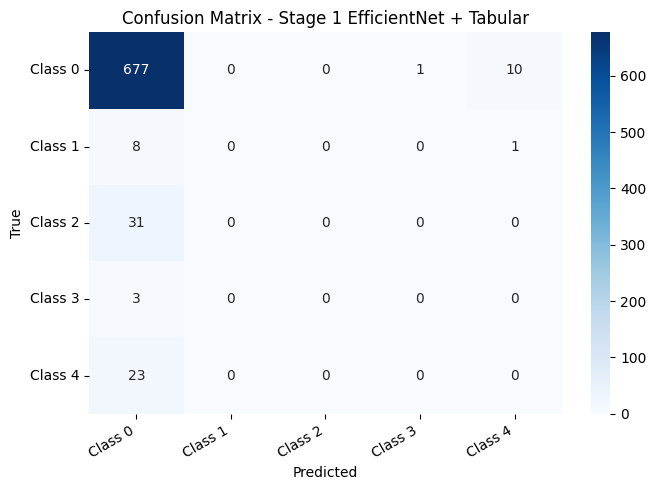

In [16]:
# =========================================================
# 14) EVALUATE STAGE 1 MODEL
# =========================================================

def evaluate_predictions(y_true, y_pred, title, class_names):
    print(title)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
    print("Macro F1:", f1_score(y_true, y_pred, average="macro", zero_division=0))
    print("Weighted F1:", f1_score(y_true, y_pred, average="weighted", zero_division=0))
    print("Prediction distribution:")
    print(pd.Series(y_pred).value_counts().sort_index())
    print("True distribution:")
    print(pd.Series(y_true).value_counts().sort_index())
    print("Classification Report:")
    print(classification_report(y_true, y_pred, labels=list(range(NUM_CLASSES)), target_names=class_names, zero_division=0))


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

stage1_val_prob = stage1_model.predict(val_ds, verbose=1)
stage1_val_pred = np.argmax(stage1_val_prob, axis=1)

stage1_test_prob = stage1_model.predict(test_ds, verbose=1)
stage1_test_pred = np.argmax(stage1_test_prob, axis=1)

stage1_val_macro_f1 = f1_score(y_val, stage1_val_pred, average="macro", zero_division=0)
stage1_val_acc = accuracy_score(y_val, stage1_val_pred)

evaluate_predictions(y_test, stage1_test_pred, "Stage 1 Test Evaluation", CLASS_NAMES)
plot_confusion(y_test, stage1_test_pred, "Confusion Matrix - Stage 1 EfficientNet + Tabular")

## **Stage 2: Extract Fine-tuned Embeddings and Build Patient Graph**

In [17]:
# =========================================================
# 15) BUILD GRAPH DATAFRAME FROM ORIGINAL PATIENTS
# =========================================================

train_graph_df = train_df.copy()
val_graph_df = val_df.copy()
test_graph_df = test_df.copy()

train_graph_df["split"] = "train"
val_graph_df["split"] = "val"
test_graph_df["split"] = "test"

graph_df = pd.concat([train_graph_df, val_graph_df, test_graph_df], axis=0).reset_index(drop=True)
graph_df[TARGET] = graph_df[TARGET].astype(int)

y_all_np = graph_df[TARGET].values.astype("int32")
train_mask_np = (graph_df["split"] == "train").values.astype("float32")
val_mask_np = (graph_df["split"] == "val").values.astype("float32")
test_mask_np = (graph_df["split"] == "test").values.astype("float32")

train_indices = np.where(train_mask_np == 1)[0]
val_indices = np.where(val_mask_np == 1)[0]
test_indices = np.where(test_mask_np == 1)[0]

print("graph_df shape:", graph_df.shape)
print(graph_df["split"].value_counts())
print("Target distribution by split:")
print(pd.crosstab(graph_df["split"], graph_df[TARGET]))

graph_df shape: (7612, 14)
split
train    6094
val       764
test      754
Name: count, dtype: int64
Target distribution by split:
target     0   1    2   3    4
split                         
test     688   9   31   3   23
train   5658  60  170  38  168
val      719   5   24   3   13


In [18]:
# =========================================================
# 16) TABULAR FEATURES FOR GRAPH NODES
# =========================================================

X_graph_tab_raw = prepare_tabular_df(graph_df, tabular_features)
train_rows = graph_df["split"] == "train"

graph_tab_imputer = SimpleImputer(strategy="median")
graph_tab_scaler = StandardScaler()

X_graph_tab_train = graph_tab_imputer.fit_transform(X_graph_tab_raw.loc[train_rows])
X_graph_tab_train = graph_tab_scaler.fit_transform(X_graph_tab_train)

X_graph_tab_all = graph_tab_imputer.transform(X_graph_tab_raw)
X_graph_tab_all = graph_tab_scaler.transform(X_graph_tab_all).astype("float32")

print("X_graph_tab_all:", X_graph_tab_all.shape)

X_graph_tab_all: (7612, 9)


In [19]:
# =========================================================
# 17) EXTRACT TRAINED LEFT/RIGHT IMAGE EMBEDDINGS
# =========================================================

def make_image_only_dataset(paths, batch_size=16):
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(lambda p: load_image(p), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

left_ds_emb = make_image_only_dataset(graph_df["left_image_path"].values, batch_size=EMB_BATCH_SIZE)
right_ds_emb = make_image_only_dataset(graph_df["right_image_path"].values, batch_size=EMB_BATCH_SIZE)

left_img_emb = image_encoder.predict(left_ds_emb, verbose=1).astype("float32")
right_img_emb = image_encoder.predict(right_ds_emb, verbose=1).astype("float32")

print("left_img_emb :", left_img_emb.shape)
print("right_img_emb:", right_img_emb.shape)

476/476 [==============================] - 19s 40ms/step
left_img_emb : (7612, 256)
right_img_emb: (7612, 256)


In [20]:
# =========================================================
# 18) FINAL NODE FEATURE MATRIX
# =========================================================

X_nodes_np = np.concatenate([left_img_emb, right_img_emb, X_graph_tab_all], axis=1).astype("float32")

print("X_nodes_np:", X_nodes_np.shape)
print("y_all_np  :", y_all_np.shape)

X_nodes_np: (7612, 521)
y_all_np  : (7612,)


In [21]:
# =========================================================
# 19) BUILD PATIENT SIMILARITY GRAPH
# =========================================================

graph_feature_scaler = StandardScaler()
X_graph_features_train = graph_feature_scaler.fit_transform(X_nodes_np[train_indices])
X_graph_features_all = graph_feature_scaler.transform(X_nodes_np).astype("float32")

n_components = min(PCA_COMPONENTS_FOR_GRAPH, X_graph_features_all.shape[1], len(train_indices) - 1)
print("PCA components used for graph:", n_components)

pca_graph = PCA(n_components=n_components, random_state=SEED)
pca_graph.fit(X_graph_features_train)
X_edge_all = pca_graph.transform(X_graph_features_all).astype("float32")

nbrs = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, metric="euclidean")
nbrs.fit(X_edge_all)
distances, indices = nbrs.kneighbors(X_edge_all)

edge_src = []
edge_dst = []
num_nodes = len(graph_df)

for i in range(num_nodes):
    for j in indices[i]:
        if i == j:
            continue
        edge_src.append(i)
        edge_dst.append(j)
        edge_src.append(j)
        edge_dst.append(i)

for i in range(num_nodes):
    edge_src.append(i)
    edge_dst.append(i)

edge_pairs = pd.DataFrame({"src": edge_src, "dst": edge_dst}).drop_duplicates()
edge_index_np = edge_pairs[["src", "dst"]].values.T.astype("int32")

print("Number of nodes:", num_nodes)
print("edge_index shape:", edge_index_np.shape)
print("Number of edges:", edge_index_np.shape[1])

PCA components used for graph: 96
Number of nodes: 7612
edge_index shape: (2, 73294)
Number of edges: 73294


In [22]:
# =========================================================
# 20) CONVERT GRAPH DATA TO TENSORS
# =========================================================

X_nodes = tf.constant(X_nodes_np, dtype=tf.float32)
edge_index = tf.constant(edge_index_np, dtype=tf.int32)
y_all = tf.constant(y_all_np, dtype=tf.int32)

train_mask = tf.constant(train_mask_np, dtype=tf.float32)
val_mask = tf.constant(val_mask_np, dtype=tf.float32)
test_mask = tf.constant(test_mask_np, dtype=tf.float32)

print("X_nodes:", X_nodes.shape)
print("edge_index:", edge_index.shape)
print("Train nodes:", len(train_indices))
print("Val nodes:", len(val_indices))
print("Test nodes:", len(test_indices))

X_nodes: (7612, 521)
edge_index: (2, 73294)
Train nodes: 6094
Val nodes: 764
Test nodes: 754


## **Stage 3: Patient Similarity GAT**

In [23]:
# =========================================================
# 21) CUSTOM GRAPH ATTENTION LAYERS
# =========================================================

class GraphAttentionLayer(tf.keras.layers.Layer):
    def __init__(self, out_dim, dropout_rate=0.2, alpha=0.2, **kwargs):
        super().__init__(**kwargs)
        self.out_dim = out_dim
        self.dropout_rate = dropout_rate
        self.alpha = alpha
        self.leaky_relu = tf.keras.layers.LeakyReLU(alpha=alpha)
        self.dropout = tf.keras.layers.Dropout(dropout_rate)

    def build(self, input_shape):
        feature_dim = int(input_shape[0][-1])
        self.W = self.add_weight(shape=(feature_dim, self.out_dim), initializer="glorot_uniform", trainable=True, name="W")
        self.a_src = self.add_weight(shape=(self.out_dim, 1), initializer="glorot_uniform", trainable=True, name="a_src")
        self.a_dst = self.add_weight(shape=(self.out_dim, 1), initializer="glorot_uniform", trainable=True, name="a_dst")

    def call(self, inputs, training=False, return_attention=False):
        X, edge_index = inputs
        src = edge_index[0]
        dst = edge_index[1]

        H = tf.matmul(X, self.W)
        H_src = tf.gather(H, src)
        H_dst = tf.gather(H, dst)

        e = self.leaky_relu(tf.matmul(H_src, self.a_src) + tf.matmul(H_dst, self.a_dst))
        e = tf.squeeze(e, axis=-1)

        num_nodes = tf.shape(X)[0]
        max_per_dst = tf.math.unsorted_segment_max(e, dst, num_segments=num_nodes)
        e_exp = tf.exp(e - tf.gather(max_per_dst, dst))
        denom = tf.math.unsorted_segment_sum(e_exp, dst, num_segments=num_nodes)
        attention = e_exp / (tf.gather(denom, dst) + 1e-9)
        attention = self.dropout(attention, training=training)

        messages = H_src * tf.expand_dims(attention, axis=-1)
        out = tf.math.unsorted_segment_sum(messages, dst, num_segments=num_nodes)

        if return_attention:
            return out, attention
        return out


class MultiHeadGAT(tf.keras.layers.Layer):
    def __init__(self, out_dim, num_heads=4, concat=True, dropout_rate=0.2, **kwargs):
        super().__init__(**kwargs)
        self.heads = [
            GraphAttentionLayer(out_dim=out_dim, dropout_rate=dropout_rate, name=f"gat_head_{i}")
            for i in range(num_heads)
        ]
        self.concat = concat

    def call(self, inputs, training=False):
        outputs = [head(inputs, training=training) for head in self.heads]
        if self.concat:
            return tf.concat(outputs, axis=-1)
        return tf.reduce_mean(tf.stack(outputs, axis=0), axis=0)

In [24]:
# =========================================================
# 22) PATIENT SIMILARITY GAT MODEL
# =========================================================

class PatientGATModel(tf.keras.Model):
    def __init__(self, hidden_dim=64, num_heads=4, num_classes=5, dropout_rate=0.25):
        super().__init__()
        self.input_dense = tf.keras.layers.Dense(160, activation="relu")
        self.input_dropout = tf.keras.layers.Dropout(dropout_rate)

        self.gat1 = MultiHeadGAT(out_dim=hidden_dim, num_heads=num_heads, concat=True, dropout_rate=dropout_rate)
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)

        self.gat2 = GraphAttentionLayer(out_dim=hidden_dim, dropout_rate=dropout_rate)
        self.bn2 = tf.keras.layers.BatchNormalization()
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)

        self.classifier_hidden = tf.keras.layers.Dense(64, activation="relu")
        self.classifier_dropout = tf.keras.layers.Dropout(dropout_rate)
        self.classifier = tf.keras.layers.Dense(num_classes, activation="softmax", name="dr_icdr_classifier")

    def call(self, inputs, training=False):
        X, edge_index = inputs
        x = self.input_dense(X)
        x = self.input_dropout(x, training=training)

        x = self.gat1([x, edge_index], training=training)
        x = tf.nn.elu(x)
        x = self.bn1(x, training=training)
        x = self.dropout1(x, training=training)

        x = self.gat2([x, edge_index], training=training)
        x = tf.nn.elu(x)
        x = self.bn2(x, training=training)
        x = self.dropout2(x, training=training)

        x = self.classifier_hidden(x)
        x = self.classifier_dropout(x, training=training)
        return self.classifier(x)


gat_model = PatientGATModel(hidden_dim=64, num_heads=4, num_classes=NUM_CLASSES, dropout_rate=0.25)
dummy_output = gat_model([X_nodes, edge_index], training=False)
print("GAT output shape:", dummy_output.shape)

GAT output shape: (7612, 5)


In [25]:
# =========================================================
# 23) GAT LOSS WITH 5-CLASS SOFT CLASS WEIGHTS
# =========================================================

# Softer gamma and weights avoid the previous failure mode where the model predicted too many minority classes.
def sparse_categorical_focal_loss_per_sample(y_true, y_pred, gamma=0.9):
    y_true = tf.cast(y_true, tf.int32)
    y_true_one_hot = tf.one_hot(y_true, depth=NUM_CLASSES)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

    ce = -y_true_one_hot * tf.math.log(y_pred)
    focal_factor = tf.pow(1.0 - y_pred, gamma)
    loss = focal_factor * ce
    return tf.reduce_sum(loss, axis=-1)


def get_graph_class_weights():
    # 5-class DR_ICDR-specific weights.
    # Class 3/4 are boosted, but not aggressively enough to destroy class 0.
    return {0: 1.0, 1: 2.0, 2: 2.2, 3: 3.2, 4: 3.2}


graph_class_weights = get_graph_class_weights()
class_weight_vector = tf.constant([graph_class_weights[i] for i in range(NUM_CLASSES)], dtype=tf.float32)
print("Graph class weights:", graph_class_weights)


def masked_weighted_focal_loss(y_true, y_pred, mask):
    per_sample_loss = sparse_categorical_focal_loss_per_sample(y_true, y_pred, gamma=0.9)
    label_weights = tf.gather(class_weight_vector, y_true)
    weighted_loss = per_sample_loss * label_weights * mask
    return tf.reduce_sum(weighted_loss) / (tf.reduce_sum(mask) + 1e-9)


def masked_accuracy(y_true, y_pred, mask):
    preds = tf.argmax(y_pred, axis=1, output_type=tf.int32)
    correct = tf.cast(tf.equal(preds, y_true), tf.float32)
    correct = correct * mask
    return tf.reduce_sum(correct) / (tf.reduce_sum(mask) + 1e-9)

Graph class weights: {0: 1.0, 1: 2.0, 2: 2.2, 3: 3.2, 4: 3.2}


In [26]:
# =========================================================
# 24) TRAIN GAT WITH 5-CLASS MACRO F1 MONITORING
# =========================================================

optimizer = tf.keras.optimizers.Adam(learning_rate=7e-5)
EPOCHS = 180
PATIENCE = 40
MIN_DELTA = 1e-4

best_val_metric = -np.inf
best_weights = None
wait = 0

history_gat = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_bal_acc": [],
    "val_macro_f1": []
}


def get_split_metrics(y_true_np, y_pred_np, indices):
    y_t = y_true_np[indices]
    y_p = y_pred_np[indices]
    acc = np.mean(y_t == y_p)
    bal_acc = balanced_accuracy_score(y_t, y_p)
    macro_f1 = f1_score(y_t, y_p, average="macro", zero_division=0)
    pred_dist = pd.Series(y_p).value_counts().sort_index().to_dict()
    return acc, bal_acc, macro_f1, pred_dist

print("Training nodes:", len(train_indices))
print("Validation nodes:", len(val_indices))
print("Training started...")

for epoch in range(1, EPOCHS + 1):
    with tf.GradientTape() as tape:
        y_pred_all_train = gat_model([X_nodes, edge_index], training=True)
        train_loss = masked_weighted_focal_loss(y_all, y_pred_all_train, train_mask)

    grads = tape.gradient(train_loss, gat_model.trainable_variables)
    grads_and_vars = [(g, v) for g, v in zip(grads, gat_model.trainable_variables) if g is not None]

    if len(grads_and_vars) == 0:
        raise ValueError("No gradients found. Model is not training.")

    optimizer.apply_gradients(grads_and_vars)

    y_pred_all_eval = gat_model([X_nodes, edge_index], training=False)
    val_loss = masked_weighted_focal_loss(y_all, y_pred_all_eval, val_mask)
    train_acc_tf = masked_accuracy(y_all, y_pred_all_eval, train_mask)
    val_acc_tf = masked_accuracy(y_all, y_pred_all_eval, val_mask)

    y_prob_np = y_pred_all_eval.numpy()
    y_pred_np = np.argmax(y_prob_np, axis=1)

    train_acc, train_bal_acc, train_macro_f1, train_pred_dist = get_split_metrics(y_all_np, y_pred_np, train_indices)
    val_acc, val_bal_acc, val_macro_f1, val_pred_dist = get_split_metrics(y_all_np, y_pred_np, val_indices)

    history_gat["train_loss"].append(float(train_loss))
    history_gat["val_loss"].append(float(val_loss))
    history_gat["train_acc"].append(float(train_acc_tf))
    history_gat["val_acc"].append(float(val_acc_tf))
    history_gat["val_bal_acc"].append(float(val_bal_acc))
    history_gat["val_macro_f1"].append(float(val_macro_f1))

    # Macro F1 is primary. Balanced accuracy stabilizes selection if macro F1 ties.
    current_metric = val_macro_f1 + 0.10 * val_bal_acc
    if current_metric > best_val_metric + MIN_DELTA:
        best_val_metric = current_metric
        best_weights = copy.deepcopy(gat_model.get_weights())
        wait = 0
        improved = "*"
    else:
        wait += 1
        improved = ""

    print(
        f"Epoch {epoch:03d} {improved} | "
        f"Train Loss: {float(train_loss):.4f} | "
        f"Val Loss: {float(val_loss):.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val BalAcc: {val_bal_acc:.4f} | "
        f"Val MacroF1: {val_macro_f1:.4f} | "
        f"Val Pred Dist: {val_pred_dist}"
    )

    if wait >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

if best_weights is not None:
    gat_model.set_weights(best_weights)
    print("Restored best GAT weights.")
    print("Best validation selection metric:", best_val_metric)
else:
    print("No best GAT weights saved.")

Training nodes: 6094
Validation nodes: 764
Training started...
Epoch 001 * | Train Loss: 1.9485 | Val Loss: 1.3539 | Train Acc: 0.5579 | Val Acc: 0.5733 | Val BalAcc: 0.1460 | Val MacroF1: 0.1569 | Val Pred Dist: {0: 453, 1: 139, 2: 119, 3: 52, 4: 1}
Epoch 002 * | Train Loss: 1.8991 | Val Loss: 1.3451 | Train Acc: 0.6026 | Val Acc: 0.6243 | Val BalAcc: 0.1568 | Val MacroF1: 0.1655 | Val Pred Dist: {0: 494, 1: 125, 2: 107, 3: 38}
Epoch 003 * | Train Loss: 1.8559 | Val Loss: 1.3368 | Train Acc: 0.6467 | Val Acc: 0.6728 | Val BalAcc: 0.1671 | Val MacroF1: 0.1738 | Val Pred Dist: {0: 531, 1: 113, 2: 93, 3: 27}
Epoch 004 * | Train Loss: 1.8493 | Val Loss: 1.3282 | Train Acc: 0.6904 | Val Acc: 0.7107 | Val BalAcc: 0.1672 | Val MacroF1: 0.1766 | Val Pred Dist: {0: 564, 1: 101, 2: 77, 3: 22}
Epoch 005 * | Train Loss: 1.7917 | Val Loss: 1.3201 | Train Acc: 0.7258 | Val Acc: 0.7579 | Val BalAcc: 0.1772 | Val MacroF1: 0.1838 | Val Pred Dist: {0: 602, 1: 84, 2: 64, 3: 14}
Epoch 006 * | Train Loss:

## **Evaluation and Final Model Selection**

Stage 1 validation accuracy: 0.9293193717277487
Stage 1 validation Macro F1: 0.2593297101449275
GAT validation accuracy: 0.9489528795811518
GAT validation Macro F1: 0.3156308241268099
Selected final model: GAT

Final Selected Model Test Evaluation: GAT
Accuracy: 0.9270557029177718
Balanced Accuracy: 0.29565217391304344
Macro F1: 0.31843137254901965
Weighted F1: 0.8984136890830604
Prediction distribution:
0    740
2      2
4     12
Name: count, dtype: int64
True distribution:
0    688
1      9
2     31
3      3
4     23
Name: count, dtype: int64
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.93      1.00      0.96       688
     Class 1       0.00      0.00      0.00         9
     Class 2       0.00      0.00      0.00        31
     Class 3       0.00      0.00      0.00         3
     Class 4       0.92      0.48      0.63        23

    accuracy                           0.93       754
   macro avg       0.37      0.30      0.32   

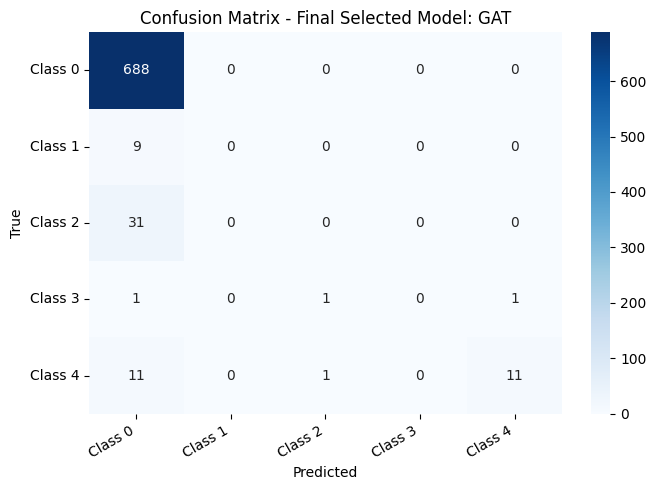

In [27]:
# =========================================================
# 25) FINAL EVALUATION: STAGE 1 VS GAT
# =========================================================

# Stage 1 metrics already computed earlier.
print("Stage 1 validation accuracy:", stage1_val_acc)
print("Stage 1 validation Macro F1:", stage1_val_macro_f1)

# GAT validation and test predictions.
y_prob_all = gat_model([X_nodes, edge_index], training=False).numpy()
y_pred_all = np.argmax(y_prob_all, axis=1)

gat_val_pred = y_pred_all[val_indices]
gat_test_pred = y_pred_all[test_indices]

gat_val_macro_f1 = f1_score(y_all_np[val_indices], gat_val_pred, average="macro", zero_division=0)
gat_val_acc = accuracy_score(y_all_np[val_indices], gat_val_pred)

print("GAT validation accuracy:", gat_val_acc)
print("GAT validation Macro F1:", gat_val_macro_f1)

if gat_val_macro_f1 >= stage1_val_macro_f1:
    FINAL_MODEL_NAME = "GAT"
    final_y_test_pred = gat_test_pred
else:
    FINAL_MODEL_NAME = "Stage 1 EfficientNet + Tabular"
    final_y_test_pred = stage1_test_pred

print("Selected final model:", FINAL_MODEL_NAME)
print()

evaluate_predictions(y_test, final_y_test_pred, f"Final Selected Model Test Evaluation: {FINAL_MODEL_NAME}", CLASS_NAMES)
plot_confusion(y_test, final_y_test_pred, f"Confusion Matrix - Final Selected Model: {FINAL_MODEL_NAME}")

GAT Test Evaluation
Accuracy: 0.9270557029177718
Balanced Accuracy: 0.29565217391304344
Macro F1: 0.31843137254901965
Weighted F1: 0.8984136890830604
Prediction distribution:
0    740
2      2
4     12
Name: count, dtype: int64
True distribution:
0    688
1      9
2     31
3      3
4     23
Name: count, dtype: int64
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.93      1.00      0.96       688
     Class 1       0.00      0.00      0.00         9
     Class 2       0.00      0.00      0.00        31
     Class 3       0.00      0.00      0.00         3
     Class 4       0.92      0.48      0.63        23

    accuracy                           0.93       754
   macro avg       0.37      0.30      0.32       754
weighted avg       0.88      0.93      0.90       754



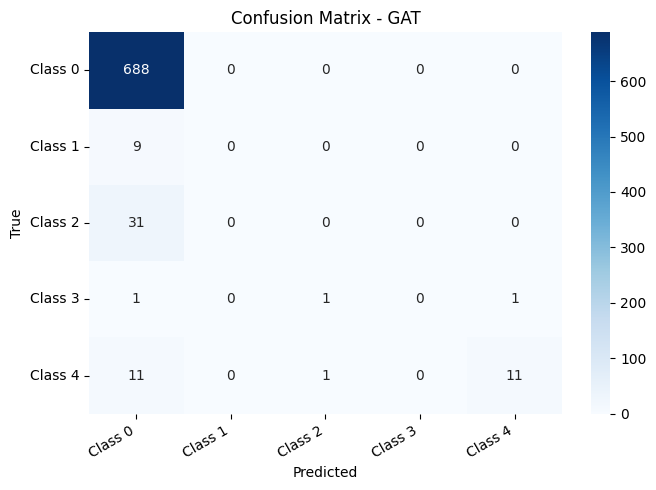

In [28]:
# =========================================================
# 26) DETAILED GAT TEST EVALUATION
# =========================================================

evaluate_predictions(y_all_np[test_indices], gat_test_pred, "GAT Test Evaluation", CLASS_NAMES)
plot_confusion(y_all_np[test_indices], gat_test_pred, "Confusion Matrix - GAT")

## 5-Class Calibration: Validation Threshold Tuning

Initial validation macro F1: 0.3156308241268099
Initial validation balanced accuracy: 0.28525641025641024
Pass 1 | thresholds: {4: 0.2, 3: 0.175, 2: 1.1, 1: 0.225} | score: 0.6120
Pass 2 | thresholds: {4: 0.2, 3: 0.175, 2: 1.1, 1: 0.225} | score: 0.6120

Best thresholds: {4: 0.2, 3: 0.175, 2: 1.1, 1: 0.225}
Validation Evaluation After 5-Class Calibration
Accuracy: 0.943717277486911
Balanced Accuracy: 0.5487350665097536
Macro F1: 0.5014248895434463
Weighted F1: 0.9303070952432357
Prediction distribution:
0    736
1      5
3      4
4     19
Name: count, dtype: int64
True distribution:
0    719
1      5
2     24
3      3
4     13
Name: count, dtype: int64
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.96      0.98      0.97       719
     Class 1       0.40      0.40      0.40         5
     Class 2       0.00      0.00      0.00        24
     Class 3       0.50      0.67      0.57         3
     Class 4       0.47      0.69      0.56  

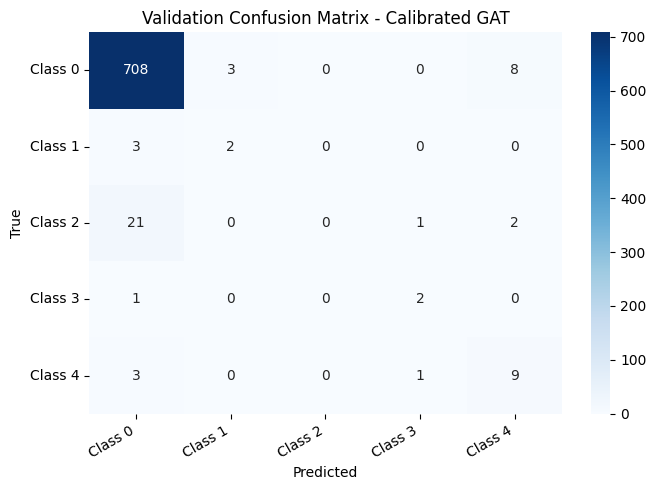

In [29]:

# =========================================================
# 27) 5-CLASS VALIDATION THRESHOLD CALIBRATION
# =========================================================

# Argmax is often weak for imbalanced 5-class DR_ICDR.
# This calibration uses validation probabilities to tune class-specific thresholds.
# Priority is from most clinically severe to least: 4 -> 3 -> 2 -> 1.

val_prob_for_calib = y_prob_all[val_indices]
val_true_for_calib = y_all_np[val_indices]
test_prob_for_calib = y_prob_all[test_indices]
test_true_for_calib = y_all_np[test_indices]

PRIORITY_CLASSES = [4, 3, 2, 1]
threshold_grid = np.round(np.arange(0.05, 0.76, 0.025), 3)


def predict_with_thresholds(y_prob, thresholds, priority_classes=PRIORITY_CLASSES):
    y_pred = np.argmax(y_prob, axis=1).copy()

    # Apply in priority order. Class 4 has first chance because missing severe cases is costly.
    for cls in priority_classes:
        thr = thresholds.get(cls, 1.1)
        mask = y_prob[:, cls] >= thr
        y_pred[mask] = cls

    return y_pred


def score_thresholds(y_true, y_pred):
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    # Weighted score favors macro F1 but keeps balanced accuracy useful.
    return macro_f1 + 0.15 * bal_acc + 0.03 * acc

# Start from thresholds that mean "almost argmax only".
best_thresholds = {cls: 1.1 for cls in PRIORITY_CLASSES}
best_pred = predict_with_thresholds(val_prob_for_calib, best_thresholds)
best_score = score_thresholds(val_true_for_calib, best_pred)

print("Initial validation macro F1:", f1_score(val_true_for_calib, best_pred, average="macro", zero_division=0))
print("Initial validation balanced accuracy:", balanced_accuracy_score(val_true_for_calib, best_pred))

# Coordinate search: tune one class threshold at a time, repeat several passes.
for pass_id in range(4):
    improved = False
    for cls in PRIORITY_CLASSES:
        local_best_thr = best_thresholds[cls]
        local_best_score = best_score

        for thr in threshold_grid:
            candidate_thresholds = best_thresholds.copy()
            candidate_thresholds[cls] = float(thr)
            candidate_pred = predict_with_thresholds(val_prob_for_calib, candidate_thresholds)
            candidate_score = score_thresholds(val_true_for_calib, candidate_pred)

            if candidate_score > local_best_score:
                local_best_score = candidate_score
                local_best_thr = float(thr)

        if local_best_score > best_score:
            best_thresholds[cls] = local_best_thr
            best_score = local_best_score
            improved = True

    print(f"Pass {pass_id + 1} | thresholds: {best_thresholds} | score: {best_score:.4f}")
    if not improved:
        break

val_pred_calibrated = predict_with_thresholds(val_prob_for_calib, best_thresholds)
print("\nBest thresholds:", best_thresholds)
evaluate_predictions(val_true_for_calib, val_pred_calibrated, "Validation Evaluation After 5-Class Calibration", CLASS_NAMES)
plot_confusion(val_true_for_calib, val_pred_calibrated, "Validation Confusion Matrix - Calibrated GAT")


Test Evaluation - Calibrated 5-Class GAT
Accuracy: 0.9190981432360743
Balanced Accuracy: 0.47892792944612966
Macro F1: 0.4409896635460545
Weighted F1: 0.8991016386162076
Prediction distribution:
0    718
1      4
3      6
4     26
Name: count, dtype: int64
True distribution:
0    688
1      9
2     31
3      3
4     23
Name: count, dtype: int64
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.94      0.98      0.96       688
     Class 1       0.50      0.22      0.31         9
     Class 2       0.00      0.00      0.00        31
     Class 3       0.33      0.67      0.44         3
     Class 4       0.46      0.52      0.49        23

    accuracy                           0.92       754
   macro avg       0.45      0.48      0.44       754
weighted avg       0.88      0.92      0.90       754



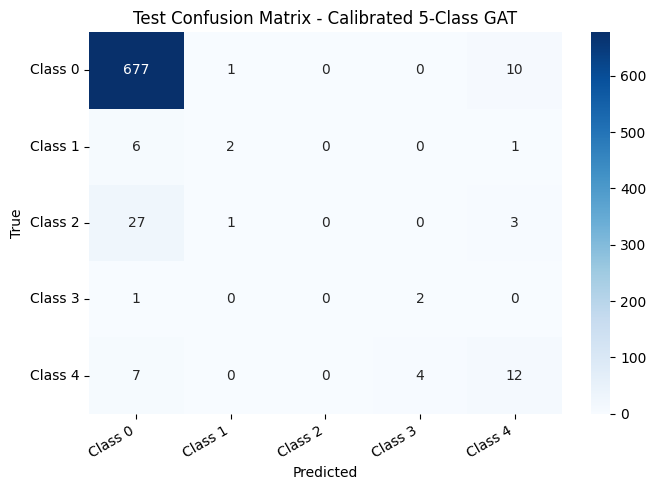

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,pred_dist
0,GAT argmax,0.927056,0.295652,0.318431,0.898414,"{0: 740, 2: 2, 4: 12}"
1,GAT calibrated,0.919098,0.478928,0.440990,0.899102,"{0: 718, 1: 4, 3: 6, 4: 26}"
2,Stage 1 argmax,0.897878,0.196802,0.189371,0.863972,"{0: 742, 3: 1, 4: 11}"


Final model updated to: Calibrated 5-Class GAT


In [30]:

# =========================================================
# 28) TEST EVALUATION AFTER 5-CLASS THRESHOLD CALIBRATION
# =========================================================

calibrated_test_pred = predict_with_thresholds(test_prob_for_calib, best_thresholds)

evaluate_predictions(test_true_for_calib, calibrated_test_pred, "Test Evaluation - Calibrated 5-Class GAT", CLASS_NAMES)
plot_confusion(test_true_for_calib, calibrated_test_pred, "Test Confusion Matrix - Calibrated 5-Class GAT")

# Compare uncalibrated GAT vs calibrated GAT.
comparison_rows = []
for name, pred in [
    ("GAT argmax", gat_test_pred),
    ("GAT calibrated", calibrated_test_pred),
    ("Stage 1 argmax", stage1_test_pred),
]:
    comparison_rows.append({
        "model": name,
        "accuracy": accuracy_score(test_true_for_calib, pred),
        "balanced_accuracy": balanced_accuracy_score(test_true_for_calib, pred),
        "macro_f1": f1_score(test_true_for_calib, pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(test_true_for_calib, pred, average="weighted", zero_division=0),
        "pred_dist": pd.Series(pred).value_counts().sort_index().to_dict()
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

# Update final prediction if calibration is better on validation.
calib_val_macro = f1_score(val_true_for_calib, val_pred_calibrated, average="macro", zero_division=0)
if calib_val_macro >= gat_val_macro_f1 and calib_val_macro >= stage1_val_macro_f1:
    FINAL_MODEL_NAME = "Calibrated 5-Class GAT"
    final_y_test_pred = calibrated_test_pred
    print("Final model updated to:", FINAL_MODEL_NAME)
else:
    print("Calibration did not beat the current validation macro F1 selection. Keeping:", FINAL_MODEL_NAME)


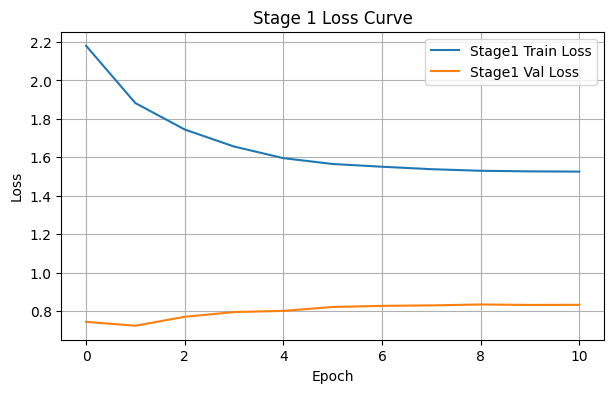

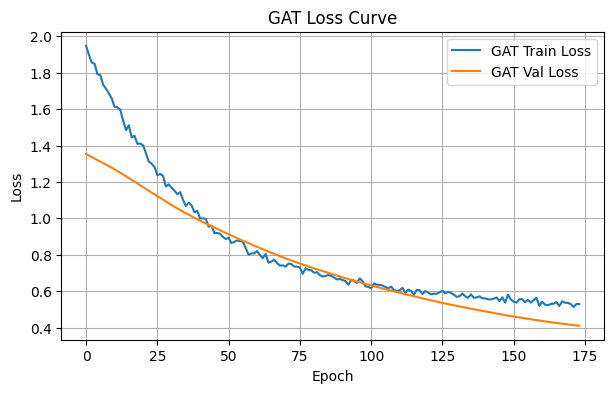

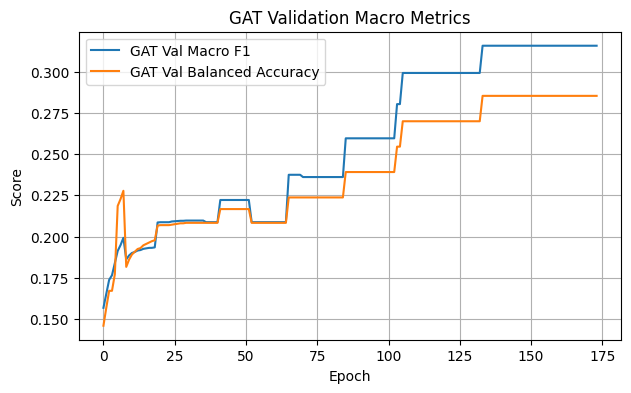

In [31]:
# =========================================================
# 27) TRAINING CURVES
# =========================================================

plt.figure(figsize=(7, 4))
plt.plot(history_stage1.history.get("loss", []), label="Stage1 Train Loss")
plt.plot(history_stage1.history.get("val_loss", []), label="Stage1 Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 1 Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_gat["train_loss"], label="GAT Train Loss")
plt.plot(history_gat["val_loss"], label="GAT Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAT Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_gat["val_macro_f1"], label="GAT Val Macro F1")
plt.plot(history_gat["val_bal_acc"], label="GAT Val Balanced Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("GAT Validation Macro Metrics")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
# =========================================================
# 28) PREDICTION DISTRIBUTIONS BY SPLIT
# =========================================================

print("GAT train prediction distribution:")
print(pd.Series(y_pred_all[train_indices]).value_counts().sort_index())
print("GAT val prediction distribution:")
print(pd.Series(y_pred_all[val_indices]).value_counts().sort_index())
print("GAT test prediction distribution:")
print(pd.Series(y_pred_all[test_indices]).value_counts().sort_index())

print("True train distribution:")
print(pd.Series(y_all_np[train_indices]).value_counts().sort_index())
print("True val distribution:")
print(pd.Series(y_all_np[val_indices]).value_counts().sort_index())
print("True test distribution:")
print(pd.Series(y_all_np[test_indices]).value_counts().sort_index())

GAT train prediction distribution:
0    5981
2      23
4      90
Name: count, dtype: int64
GAT val prediction distribution:
0    756
2      2
4      6
Name: count, dtype: int64
GAT test prediction distribution:
0    740
2      2
4     12
Name: count, dtype: int64
True train distribution:
0    5658
1      60
2     170
3      38
4     168
Name: count, dtype: int64
True val distribution:
0    719
1      5
2     24
3      3
4     13
Name: count, dtype: int64
True test distribution:
0    688
1      9
2     31
3      3
4     23
Name: count, dtype: int64


## **XAI / Visual Explanation**

Random graph index: 6960
Patient ID: 1129
True label: 0 Class 0
Predicted label: 0 Class 0
Predicted probabilities: [0.459  0.1137 0.0864 0.1318 0.2091]
Base CNN model: efficientnetb0
Last spatial feature layer: top_activation


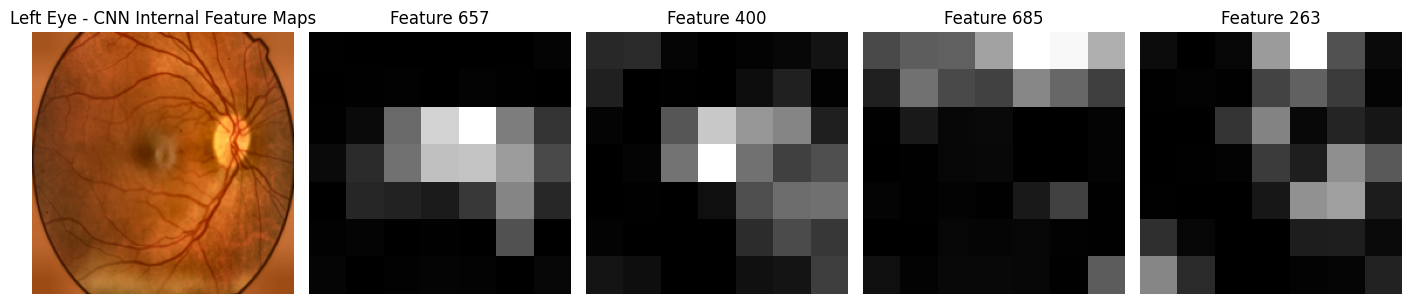

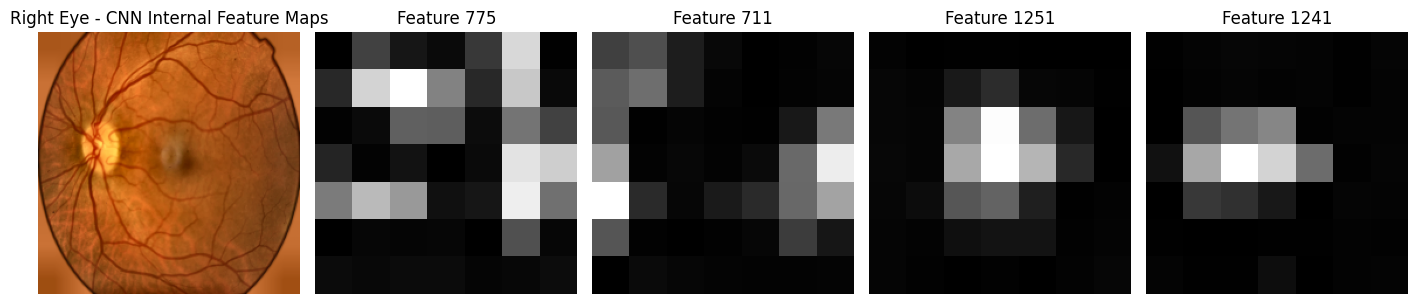

In [33]:
# =========================================================
# 29) VISUALIZE ONE RANDOM PATIENT PAIR + CNN FEATURE MAPS
# =========================================================

random_test_idx = np.random.choice(test_indices)
random_patient = graph_df.iloc[random_test_idx]

left_path = random_patient["left_image_path"]
right_path = random_patient["right_image_path"]
true_label = int(random_patient[TARGET])

if FINAL_MODEL_NAME == "GAT":
    pred_label = int(y_pred_all[random_test_idx])
    pred_probs = y_prob_all[random_test_idx]
else:
    local_test_pos = np.where(test_indices == random_test_idx)[0][0]
    pred_label = int(stage1_test_pred[local_test_pos])
    pred_probs = stage1_test_prob[local_test_pos]

print("Random graph index:", random_test_idx)
print("Patient ID:", random_patient["patient_id"])
print("True label:", true_label, CLASS_NAMES[true_label])
print("Predicted label:", pred_label, CLASS_NAMES[pred_label])
print("Predicted probabilities:", np.round(pred_probs, 4))


def load_single_image_np(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img.numpy()

base_model = None
for layer in image_encoder.layers:
    if "efficientnet" in layer.name.lower():
        base_model = layer
        break

if base_model is None:
    raise ValueError(f"Could not find EfficientNet layer. Existing layers: {[layer.name for layer in image_encoder.layers]}")

last_spatial_layer_name = None
for layer in reversed(base_model.layers):
    try:
        if len(layer.output.shape) == 4:
            last_spatial_layer_name = layer.name
            break
    except Exception:
        continue

if last_spatial_layer_name is None:
    raise ValueError("No 4D spatial layer found inside EfficientNet.")

print("Base CNN model:", base_model.name)
print("Last spatial feature layer:", last_spatial_layer_name)

base_fmap_model = Model(inputs=base_model.input, outputs=base_model.get_layer(last_spatial_layer_name).output)


def get_feature_maps(img_np):
    x = np.expand_dims(img_np, axis=0).astype("float32") * 255.0
    fmap = base_fmap_model.predict(x, verbose=0)[0]
    return fmap


def show_top_feature_maps(img_np, fmap, title, top_k=4):
    channel_scores = fmap.mean(axis=(0, 1))
    top_channels = np.argsort(channel_scores)[-top_k:][::-1]

    plt.figure(figsize=(14, 3))
    plt.subplot(1, top_k + 1, 1)
    plt.imshow(img_np)
    plt.title(title)
    plt.axis("off")

    for idx, ch in enumerate(top_channels):
        activation = fmap[:, :, ch]
        plt.subplot(1, top_k + 1, idx + 2)
        plt.imshow(activation, cmap="gray")
        plt.title(f"Feature {ch}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

left_img_np = load_single_image_np(left_path)
right_img_np = load_single_image_np(right_path)

left_fmap = get_feature_maps(left_img_np)
right_fmap = get_feature_maps(right_img_np)

show_top_feature_maps(left_img_np, left_fmap, "Left Eye - CNN Internal Feature Maps", top_k=4)
show_top_feature_maps(right_img_np, right_fmap, "Right Eye - CNN Internal Feature Maps", top_k=4)

In [34]:
# =========================================================
# 30) GAT ATTENTION EXPLANATION FOR SAME RANDOM PATIENT
# =========================================================

x0 = gat_model.input_dense(X_nodes)
x0 = gat_model.gat1([x0, edge_index], training=False)
x0 = tf.nn.elu(x0)
x0 = gat_model.bn1(x0, training=False)

gat2_out, attention_scores = gat_model.gat2([x0, edge_index], training=False, return_attention=True)
attention_scores_np = attention_scores.numpy()
src_np = edge_index_np[0]
dst_np = edge_index_np[1]

incoming_mask = dst_np == random_test_idx
incoming_sources = src_np[incoming_mask]
incoming_attention = attention_scores_np[incoming_mask]

top_order = np.argsort(incoming_attention)[-10:][::-1]

attention_rows = []
for rank, pos in enumerate(top_order, start=1):
    neighbor_idx = incoming_sources[pos]
    att_score = incoming_attention[pos]
    row = graph_df.iloc[neighbor_idx]
    attention_rows.append({
        "rank": rank,
        "neighbor_graph_idx": int(neighbor_idx),
        "neighbor_patient_id": row["patient_id"],
        "split": row["split"],
        "neighbor_label": int(row[TARGET]),
        "neighbor_label_name": CLASS_NAMES[int(row[TARGET])],
        "attention_score": float(att_score)
    })

attention_df = pd.DataFrame(attention_rows)
print("Selected patient:")
print("Graph index:", random_test_idx)
print("Patient ID:", random_patient["patient_id"])
print("True label:", true_label, CLASS_NAMES[true_label])
print("Predicted label:", pred_label, CLASS_NAMES[pred_label])
print("Top GAT attention neighbors:")
display(attention_df)

Selected patient:
Graph index: 6960
Patient ID: 1129
True label: 0 Class 0
Predicted label: 0 Class 0
Top GAT attention neighbors:


,rank,neighbor_graph_idx,neighbor_patient_id,split,neighbor_label,neighbor_label_name,attention_score
0,1,5699,7983,train,0,Class 0,0.055058
1,2,3130,4401,train,0,Class 0,0.054456
2,3,5022,7090,train,0,Class 0,0.054365
3,4,6317,2518,val,0,Class 0,0.054328
4,5,1538,2238,train,0,Class 0,0.054030
5,6,5339,7498,train,0,Class 0,0.053654
6,7,4251,6001,train,2,Class 2,0.053408
7,8,6260,1732,val,0,Class 0,0.053371
8,9,6960,1129,test,0,Class 0,0.052783
9,10,3898,5468,train,0,Class 0,0.052743


## **Save Artifacts**

In [35]:
# =========================================================
# 31) SAVE MODEL ARTIFACTS
# =========================================================

stage1_model.save("stage1_efficientnet_tabular.keras")
gat_model.save_weights("patient_similarity_gat.weights.h5")

np.save("X_nodes_embeddings.npy", X_nodes_np)
np.save("edge_index_patient_graph.npy", edge_index_np)
np.save("y_all_graph.npy", y_all_np)

graph_df.to_csv("graph_patient_dataframe.csv", index=False)

print("Saved artifacts successfully.")

# Save calibrated test predictions when calibration cells have been executed.
try:
    np.save("calibrated_5class_test_predictions.npy", calibrated_test_pred)
    print("- calibrated_5class_test_predictions.npy")
except NameError:
    print("Calibration predictions not found; skipping calibrated prediction save.")


Saved artifacts successfully.
- calibrated_5class_test_predictions.npy
